# DAPRO LPB budget utilization across seeds

Load one merged LPB experiment, keep the default DAPRO configuration, and visualize the distribution of average calibration budget used per sample across seeds. The histogram marks the target, mean, and 5th, 10th, 50th, 90th, and 95th percentiles.

In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Make the notebook work whether Jupyter starts in the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
# One LPB setup. Change these values to point to another completed experiment.
config = {
    "dataset_name": "dataset_toxicity",
    "dataset_setup": "attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify",
    "budget_per_sample": 20.0,
    "cal_size": 3000,
    "tau_prior": 0.56,
    "is_real": True,
}

# Default DAPRO configuration: n1=100, Platt projection, probability score.
DAPRO_METHOD = "calibration_projected_optimization_platt_prob_allocation"

m_upper_bound = 200 if config["is_real"] else 20
gamma = m_upper_bound / config["budget_per_sample"]
experiment_signature = (
    f'{config["dataset_name"]}_{config["dataset_setup"]}_'
    f'{config["budget_per_sample"]}_{config["cal_size"]}_'
    f'{config["tau_prior"]}_{np.round(gamma, 3)}'
)
# dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_gemma3_4b_it_judge_detoxify_20.0_3000_0.56_10.0

results_dir = PROJECT_ROOT / "results" / "merged_calibration_dfs" / experiment_signature
csv_path = results_dir / "all_df.csv"
csv_path


PosixPath('/Users/shai.feldman/Documents/Projects/dapro_rebuttal/results/merged_calibration_dfs/dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0/all_df.csv')

In [13]:
if not csv_path.exists():
    raise FileNotFoundError(
        f"Merged LPB results were not found at {csv_path}. "
        "Run construct_calibrated_bound.py and merge_bounds_results.py for this setup first."
    )

all_df = pd.read_csv(csv_path)
required_columns = {"seed", "calibration_name", "budget_used"}
missing_columns = required_columns.difference(all_df.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

dapro_rows = all_df.loc[
    all_df["calibration_name"].eq(DAPRO_METHOD),
    ["seed", "budget_used"],
].copy()
if dapro_rows.empty:
    available = sorted(all_df["calibration_name"].dropna().unique())
    raise ValueError(
        f"No rows found for {DAPRO_METHOD}. Available methods: {available}"
    )

dapro_rows["budget_used"] = pd.to_numeric(dapro_rows["budget_used"], errors="coerce")
dapro_rows = dapro_rows.replace([np.inf, -np.inf], np.nan).dropna()

# Merged bound results contain one row per target coverage. Budget is a per-seed
# allocation statistic, so verify consistency before retaining one value per seed.
budgets_per_seed = dapro_rows.groupby("seed")["budget_used"]
inconsistent_seeds = budgets_per_seed.nunique().loc[lambda counts: counts > 1]
if not inconsistent_seeds.empty:
    raise ValueError(
        "DAPRO has multiple budget_used values for these seeds: "
        f"{inconsistent_seeds.index.tolist()}"
    )

seed_average_budgets = budgets_per_seed.first().sort_index() / config["cal_size"]
if seed_average_budgets.empty:
    raise ValueError("No finite DAPRO budget values remain after cleaning.")

target_average_budget = config["budget_per_sample"]
mean_average_budget = seed_average_budgets.mean()
quantile_levels = [0.05, 0.10, 0.50, 0.90, 0.95]
budget_quantiles = seed_average_budgets.quantile(quantile_levels)

budget_summary = pd.DataFrame(
    [
        ("Target", target_average_budget),
        ("Mean", mean_average_budget),
        *[(f"{level:.0%} quantile", budget_quantiles.loc[level]) for level in quantile_levels],
    ],
    columns=["Statistic", "Average budget per sample"],
)
budget_summary.style.format({"Average budget per sample": "{:.2f}"})


,Statistic,Average budget per sample
0,Target,20.00
1,Mean,19.86
2,5% quantile,17.88
3,10% quantile,18.47
4,50% quantile,19.68
5,90% quantile,21.47
6,95% quantile,21.64


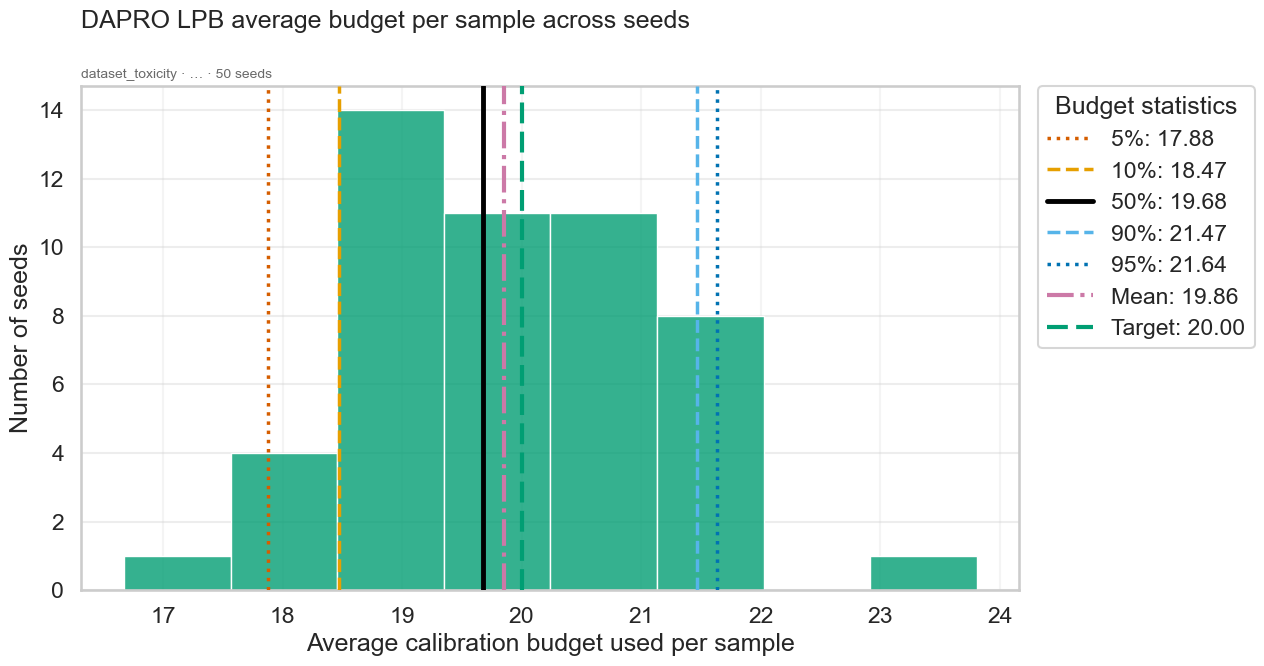

Saved figure to /Users/shai.feldman/Documents/Projects/dapro_rebuttal/notebooks/figures/calibration_results/dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0/dapro_lpb_average_budget_per_sample_histogram.png


In [14]:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(13, 7))
sns.histplot(
    seed_average_budgets,
    bins="auto",
    color=sns.color_palette("colorblind")[2],
    edgecolor="white",
    linewidth=1.0,
    alpha=0.80,
    ax=ax,
)

quantile_styles = {
    0.05: {"color": "#D55E00", "linestyle": ":",  "linewidth": 2.5},
    0.10: {"color": "#E69F00", "linestyle": "--", "linewidth": 2.5},
    0.50: {"color": "#000000", "linestyle": "-",  "linewidth": 3.5},
    0.90: {"color": "#56B4E9", "linestyle": "--", "linewidth": 2.5},
    0.95: {"color": "#0072B2", "linestyle": ":",  "linewidth": 2.5},
}

for level in quantile_levels:
    value = budget_quantiles.loc[level]
    ax.axvline(
        value,
        label=f"{level:.0%}: {value:.2f}",
        zorder=4,
        **quantile_styles[level],
    )

ax.axvline(
    mean_average_budget,
    color="#CC79A7",
    linestyle="-.",
    linewidth=3.0,
    label=f"Mean: {mean_average_budget:.2f}",
    zorder=5,
)
ax.axvline(
    target_average_budget,
    color="#009E73",
    linestyle=(0, (5, 2)),
    linewidth=3.0,
    label=f"Target: {target_average_budget:.2f}",
    zorder=5,
)

ax.set_title("DAPRO LPB average budget per sample across seeds", loc="left", pad=42)
short_setup = textwrap.shorten(config["dataset_setup"], width=72, placeholder="…")
setup_label = f'{config["dataset_name"]} · {short_setup} · {len(seed_average_budgets)} seeds'
ax.text(
    0.0,
    1.01,
    setup_label,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color="dimgray",
)
ax.set_xlabel("Average calibration budget used per sample")
ax.set_ylabel("Number of seeds")
ax.yaxis.get_major_locator().set_params(integer=True)
ax.grid(axis="x", alpha=0.20)
ax.grid(axis="y", alpha=0.35)
ax.legend(
    title="Budget statistics",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0,
    frameon=True,
)

figure_dir = PROJECT_ROOT / "notebooks" / "figures" / "calibration_results" / experiment_signature
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / "dapro_lpb_average_budget_per_sample_histogram.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to {figure_path}")


In [15]:
# Copy the contents of this Markdown code block into OpenReview.
table_rows = [
    "| Statistic | Average budget per sample |",
    "|---|---:|",
    *[
        f"| {statistic} | {value:.2f} |"
        for statistic, value in budget_summary.itertuples(index=False, name=None)
    ],
]
openreview_markdown = "\n".join(table_rows)
print(f"```markdown\n{openreview_markdown}\n```")


```markdown
| Statistic | Average budget per sample |
|---|---:|
| Target | 20.00 |
| Mean | 19.86 |
| 5% quantile | 17.88 |
| 10% quantile | 18.47 |
| 50% quantile | 19.68 |
| 90% quantile | 21.47 |
| 95% quantile | 21.64 |
```
